# Notebook 2 Machine Learning Models: Classificazione single-cell RNA-seq 

**Project 2: Classification of Cell Types**

## Modelli
- **Dummy**
- **Logistic Regression** 
- **SVM lineare** 
- **Random Forest** 
- **LightGBM** 




In [52]:
import time
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
)

def _find_root(start=None):
    p = (start or pathlib.Path.cwd()).resolve()
    for _ in range(6):
        if (p / "src" / "setup.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Radice del progetto non trovata (manca src/setup.py).")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Project root:", ROOT)


Project root: C:\Users\julie\Dev\GitHub\ML_SingleCell_Classification


## 1. Caricamento dati


In [53]:
from src.data_loader import load_datasets

X_train, X_test, y_train, y_test = load_datasets()
LABELS = sorted(y_train.unique())

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classi: {len(LABELS)}")


Train: (4516, 1976)  |  Test: (1129, 1976)
Classi: 19


### 1.1 Struttura train / test


In [70]:
def summarize_split(X_tr, X_te, y_tr, y_te, labels):
    """Shape, statistiche base e copertura classi tra train e test."""
    print("=" * 60)
    print("  RIEPILOGO DATASET")
    print("=" * 60)

    print("\nShape (righe = celle, colonne = geni):")
    print(f"  X_train {X_tr.shape}  |  X_test {X_te.shape}")
    print(f"  y_train {y_tr.shape}  |  y_test {y_te.shape}")
    print(f"  Geni: {X_tr.shape[1]}  |  Target: cell_type")

    print("\n X_test ")
    print(f"  Dtype colonne : {dict(X_te.dtypes.value_counts())}")
    print(f"  Valori nulli  : {int(X_te.isna().sum().sum())}")
    print(f"  Min / Max     : {X_te.values.min():.4f} / {X_te.values.max():.4f}")
    print(f"  Media globale : {X_te.values.mean():.4f}")

    print("\ny_test ")
    print(f"  Classe uniche : {y_te.nunique()} / {len(labels)} (train)")
    print(f"  Dtype         : {y_te.dtype}")

    train_cls = set(y_tr.unique())
    test_cls = set(y_te.unique())
    missing_in_test = sorted(train_cls - test_cls)
    extra_in_test = sorted(test_cls - train_cls)

    print("\nCopertura classi (Train vs Test)")
    print(f"  Classe uniche in train: {len(train_cls)}")
    print(f"  Classe uniche in test : {len(test_cls)}")

    if missing_in_test:
        print(f"  ATTENZIONE: in train ma assenti in test: {missing_in_test}")
    else:
        print("  OK: tutte le classi di train sono presenti in test.")

    if extra_in_test:
        print(f"  ATTENZIONE: in test ma assenti in train: {extra_in_test}")
    else:
        print("  OK: nessuna classe extra in test.")

    counts = (
        pd.DataFrame({"train": y_tr.value_counts(), "test": y_te.value_counts()})
        .fillna(0)
        .astype(int)
        .reindex(labels)
    )
    counts["train_%"] = (counts["train"] / len(y_tr) * 100).round(2)
    counts["test_%"] = (counts["test"] / len(y_te) * 100).round(2)
    counts["in_test"] = counts["test"].gt(0).map({True: "si", False: "no"})

    print("\nDistribuzione per classe")
    print(counts.to_string())

    return counts


class_summary = summarize_split(X_train, X_test, y_train, y_test, LABELS)


  RIEPILOGO DATASET

Shape (righe = celle, colonne = geni):
  X_train (4516, 1976)  |  X_test (1129, 1976)
  y_train (4516,)  |  y_test (1129,)
  Geni: 1976  |  Target: cell_type

 X_test 
  Dtype colonne : {dtype('float64'): np.int64(1976)}
  Valori nulli  : 0
  Min / Max     : -2.3518 / 42.7364
  Media globale : 0.0017

y_test 
  Classe uniche : 17 / 19 (train)
  Dtype         : str

Copertura classi (Train vs Test)
  Classe uniche in train: 19
  Classe uniche in test : 17
  ATTENZIONE: in train ma assenti in test: ['Neutrophil', 'SC & Eosinophil']
  OK: nessuna classe extra in test.

Distribuzione per classe
                  train  test  train_%  test_% in_test
cell_type                                             
B                   646   162  14.3000 14.3500      si
CD14 Monocyte      1511   378  33.4600 33.4800      si
CD16 Monocyte       133    33   2.9500  2.9200      si
CD4 T                20     5   0.4400  0.4400      si
CD4m T              108    27   2.3900  2.3900     

## 2. Creazione della struttura a oggetti per la classificazione


In [55]:
class Classifier:
    """Wrapper per addestrare, valutare e visualizzare un classificatore sklearn."""

    def __init__(self, name: str, model):
        self.name = name
        self.model = model
        self.metrics: dict = {}
        self.y_pred = None
        self._train_time = 0.0

    def fit(self, X, y):
        t0 = time.time()
        self.model.fit(X, y)
        self._train_time = round(time.time() - t0, 1)
        return self

    def evaluate(self, X, y_true):
        self.y_pred = self.model.predict(X)
        self.metrics = {
            "accuracy"         : accuracy_score(y_true, self.y_pred),
            "macro_f1"         : f1_score(y_true, self.y_pred, average="macro", zero_division=0),
            "macro_precision"  : precision_score(y_true, self.y_pred, average="macro", zero_division=0),
            "macro_recall"     : recall_score(y_true, self.y_pred, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, self.y_pred),
        }
        return self

    def print_report(self, y_true):
        m = self.metrics
        print(f"\n{'='*55}")
        print(f"  {self.name}  (tempo: {self._train_time}s)")
        print(f"{'='*55}")
        print(f"  Accuracy:          {m['accuracy']:.4f}")
        print(f"  Macro F1:          {m['macro_f1']:.4f}")
        print(f"  Macro Precision:   {m['macro_precision']:.4f}")
        print(f"  Macro Recall:      {m['macro_recall']:.4f}")
        print(f"  Balanced Accuracy: {m['balanced_accuracy']:.4f}")
        print(classification_report(y_true, self.y_pred, labels=LABELS, zero_division=0))

    def plot_confusion(self, y_true, save=True):
        cm_raw  = confusion_matrix(y_true, self.y_pred, labels=LABELS)
        cm_norm = confusion_matrix(y_true, self.y_pred, labels=LABELS, normalize="true")

        fig, axes = plt.subplots(1, 2, figsize=(20, 9))
        for ax, cm, cmap, title in zip(
            axes, [cm_raw, cm_norm], ["Blues", "Oranges"],
            [f"Conteggi — {self.name}", f"Normalizzata (recall) — {self.name}"],
        ):
            sns.heatmap(cm, cmap=cmap, xticklabels=LABELS, yticklabels=LABELS,
                        ax=ax, cbar=True, vmin=0, vmax=(None if cmap == "Blues" else 1))
            ax.set_title(title)
            ax.set_xlabel("Predetto"); ax.set_ylabel("Vero")
            plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

        plt.tight_layout()
        if save:
            fig.savefig(FIGURES_DIR / f"cm_{self.name.replace(' ', '_')}.png",
                        dpi=150, bbox_inches="tight")
        plt.show()

    def feature_importance(self, feature_names, top_n=20, save=True):
        if not hasattr(self.model, "feature_importances_"):
            print(f"{self.name}: nessuna feature importance disponibile.")
            return None
        imp = pd.Series(self.model.feature_importances_, index=feature_names)
        top = imp.sort_values(ascending=False).head(top_n)[::-1]

        fig, ax = plt.subplots(figsize=(9, 7))
        ax.barh(top.index, top.values, color="#55a868")
        ax.set_title(f"Top {top_n} geni — {self.name}", fontweight="bold")
        ax.set_xlabel("Importanza")
        plt.tight_layout()
        if save:
            fig.savefig(FIGURES_DIR / f"importance_{self.name.replace(' ', '_')}.png",
                        dpi=150, bbox_inches="tight")
        plt.show()
        return imp


## 3. Definizione dei modelli


In [56]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM non disponibile.")

N_CLASSES = len(LABELS)

model_definitions = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=42),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
    ),

    # PCA(100): scelta di velocità/regolarizzazione
    "SVM lineare": Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=100, random_state=42)),
        ("svm",    LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",   
        random_state=42,
        n_jobs=-1,
    ),
}

if HAS_LGBM:
    model_definitions["LightGBM"] = LGBMClassifier(
        objective="multiclass",
        num_class=N_CLASSES,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=8,
        min_child_samples=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

print("Modelli definiti:", list(model_definitions.keys()))


Modelli definiti: ['Dummy', 'Logistic Regression', 'SVM lineare', 'Random Forest', 'LightGBM']


## 4. Addestramento e valutazione di tutti i modelli (default)



  Dummy  (tempo: 0.0s)
  Accuracy:          0.3348
  Macro F1:          0.0295
  Macro Precision:   0.0197
  Macro Recall:      0.0588
  Balanced Accuracy: 0.0588
                  precision    recall  f1-score   support

               B       0.00      0.00      0.00       162
   CD14 Monocyte       0.33      1.00      0.50       378
   CD16 Monocyte       0.00      0.00      0.00        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.00      0.00      0.00        27
          CD4n T       0.00      0.00      0.00        54
        CD8eff T       0.00      0.00      0.00         6
          CD8m T       0.00      0.00      0.00       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.00      0.00      0.00         8
          IgA PB       0.00      0.00      0.00         3
          IgG PB       0.00      0.00      0.00         1
              NK       0.00      0.00      0.00       178
      Neutrophil       

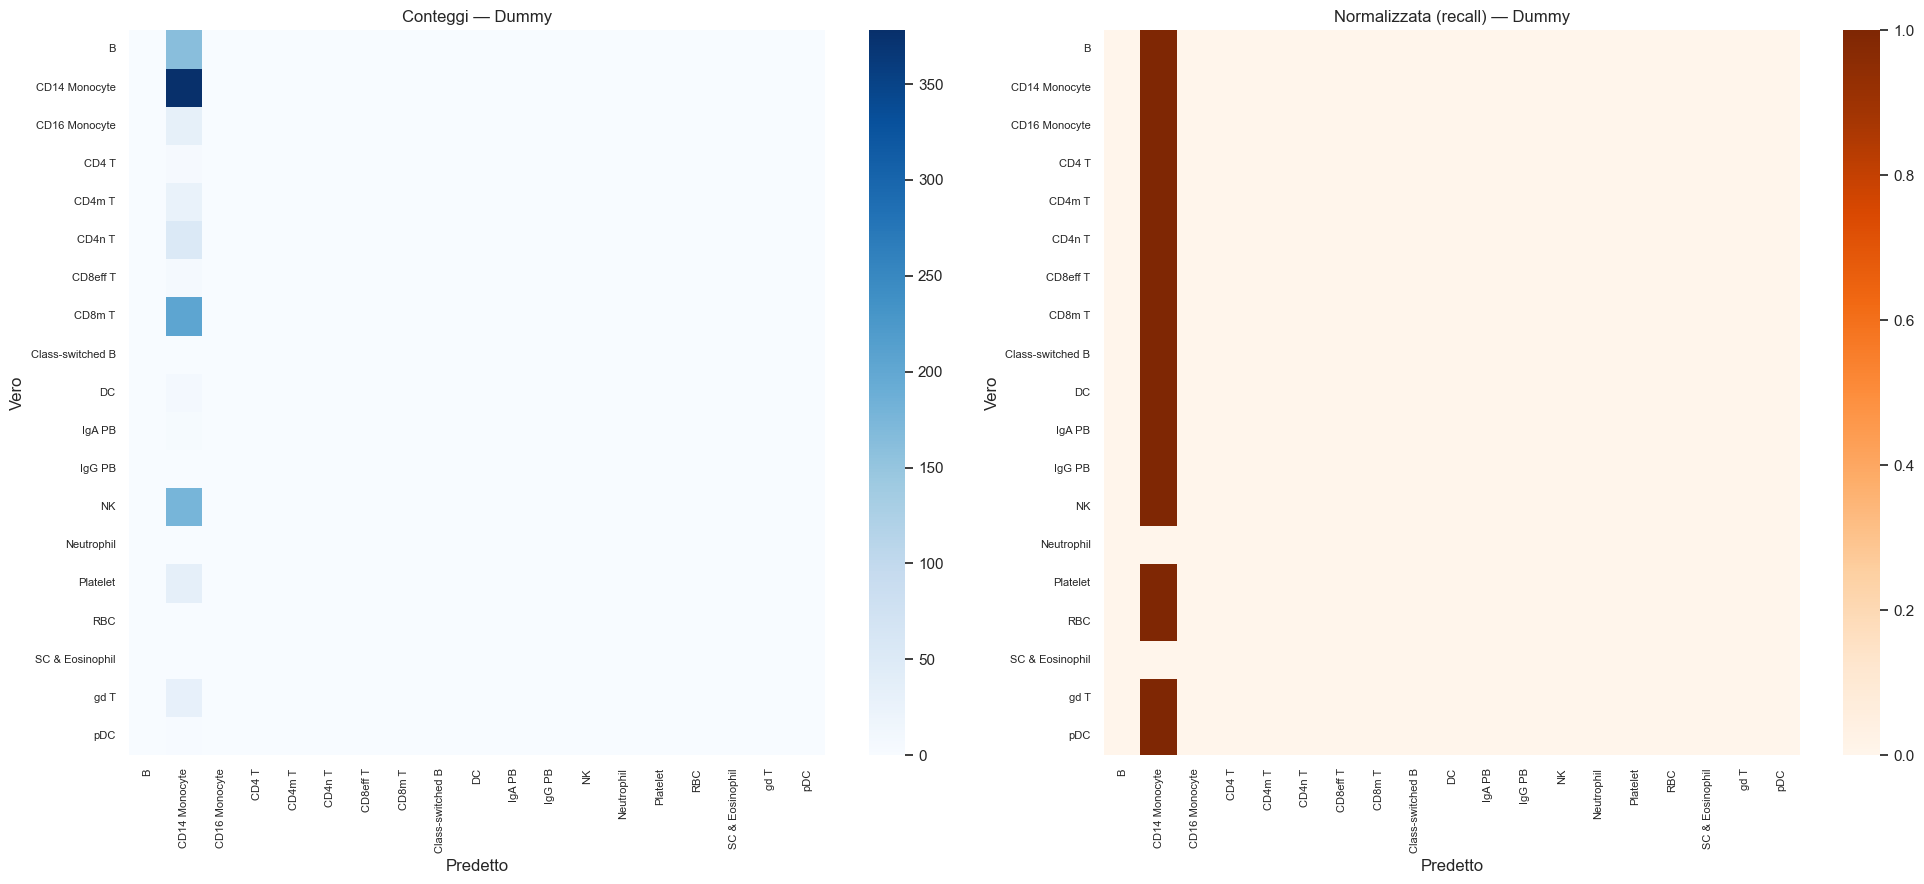


  Logistic Regression  (tempo: 0.7s)
  Accuracy:          0.8866
  Macro F1:          0.6535
  Macro Precision:   0.6415
  Macro Recall:      0.6911
  Balanced Accuracy: 0.6911
                  precision    recall  f1-score   support

               B       0.99      0.99      0.99       162
   CD14 Monocyte       0.97      0.94      0.95       378
   CD16 Monocyte       0.75      0.82      0.78        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.50      0.33      0.40        27
          CD4n T       0.77      0.80      0.78        54
        CD8eff T       0.56      0.83      0.67         6
          CD8m T       0.81      0.86      0.83       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.86      0.75      0.80         8
          IgA PB       1.00      1.00      1.00         3
          IgG PB       0.33      1.00      0.50         1
              NK       0.91      0.92      0.91       178
      Neu

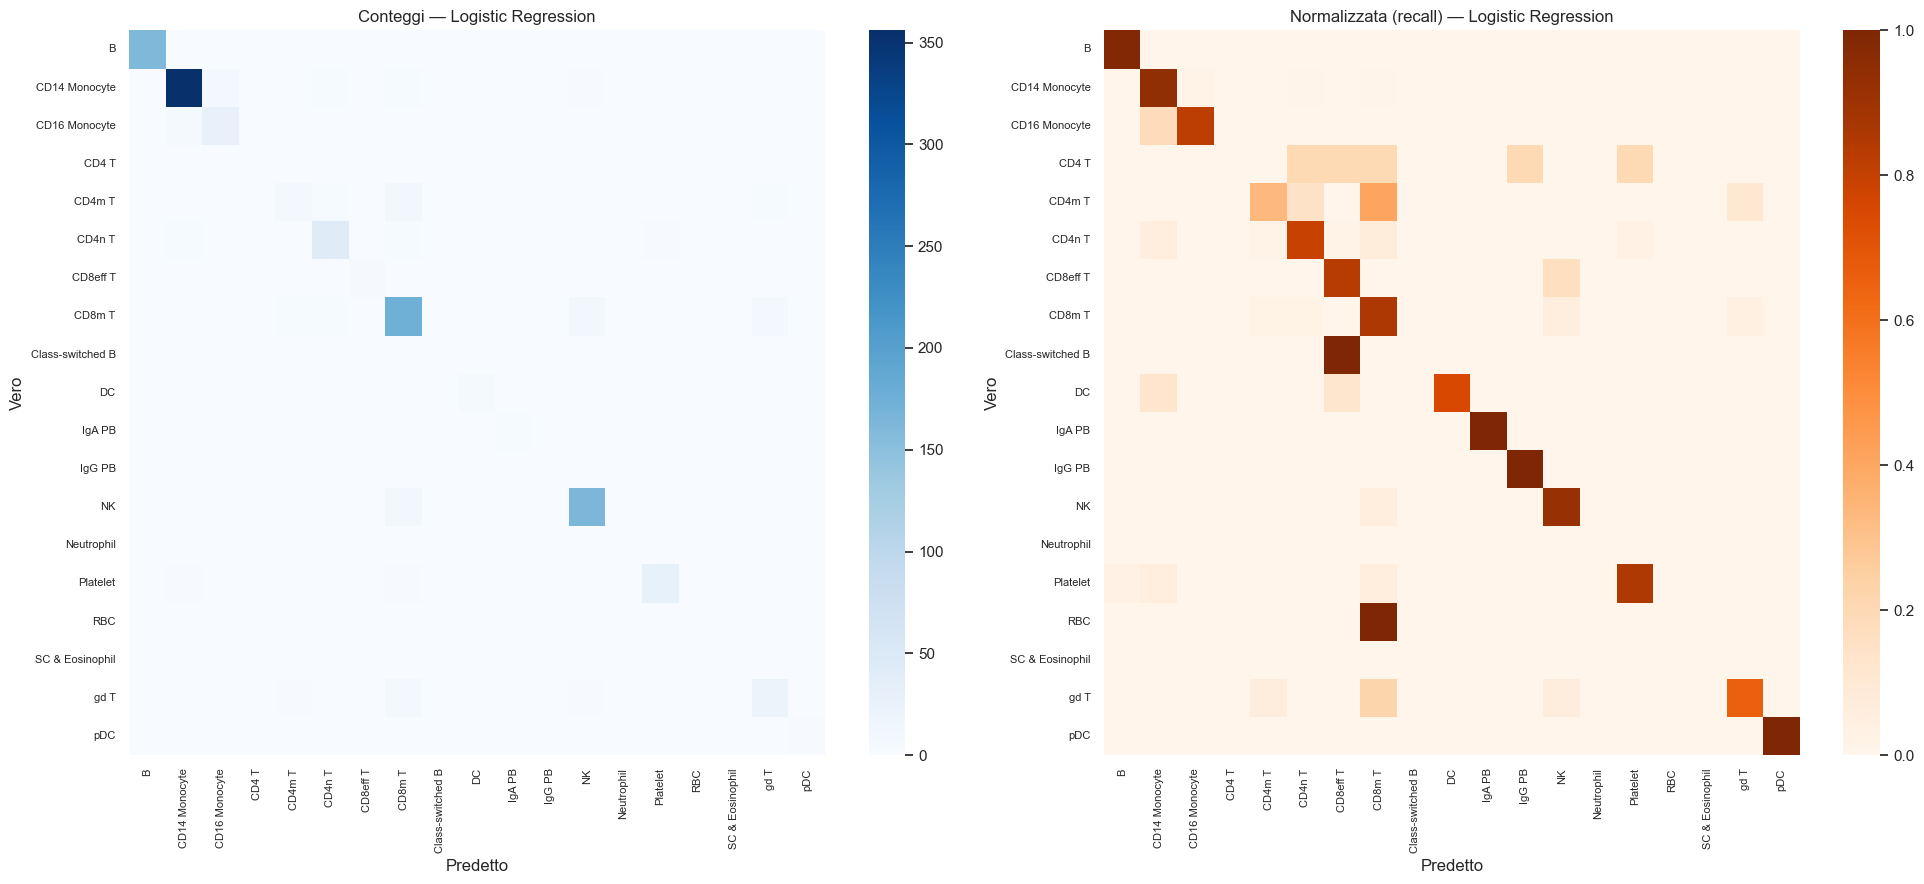


  SVM lineare  (tempo: 6.1s)
  Accuracy:          0.9017
  Macro F1:          0.6471
  Macro Precision:   0.6643
  Macro Recall:      0.6614
  Balanced Accuracy: 0.7003
                  precision    recall  f1-score   support

               B       0.99      0.99      0.99       162
   CD14 Monocyte       0.97      0.97      0.97       378
   CD16 Monocyte       0.87      0.82      0.84        33
           CD4 T       0.25      0.20      0.22         5
          CD4m T       0.47      0.59      0.52        27
          CD4n T       0.77      0.81      0.79        54
        CD8eff T       0.60      1.00      0.75         6
          CD8m T       0.89      0.82      0.85       204
Class-switched B       0.00      0.00      0.00         1
              DC       1.00      0.75      0.86         8
          IgA PB       1.00      0.33      0.50         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.90      0.93      0.91       178
      Neutrophil 

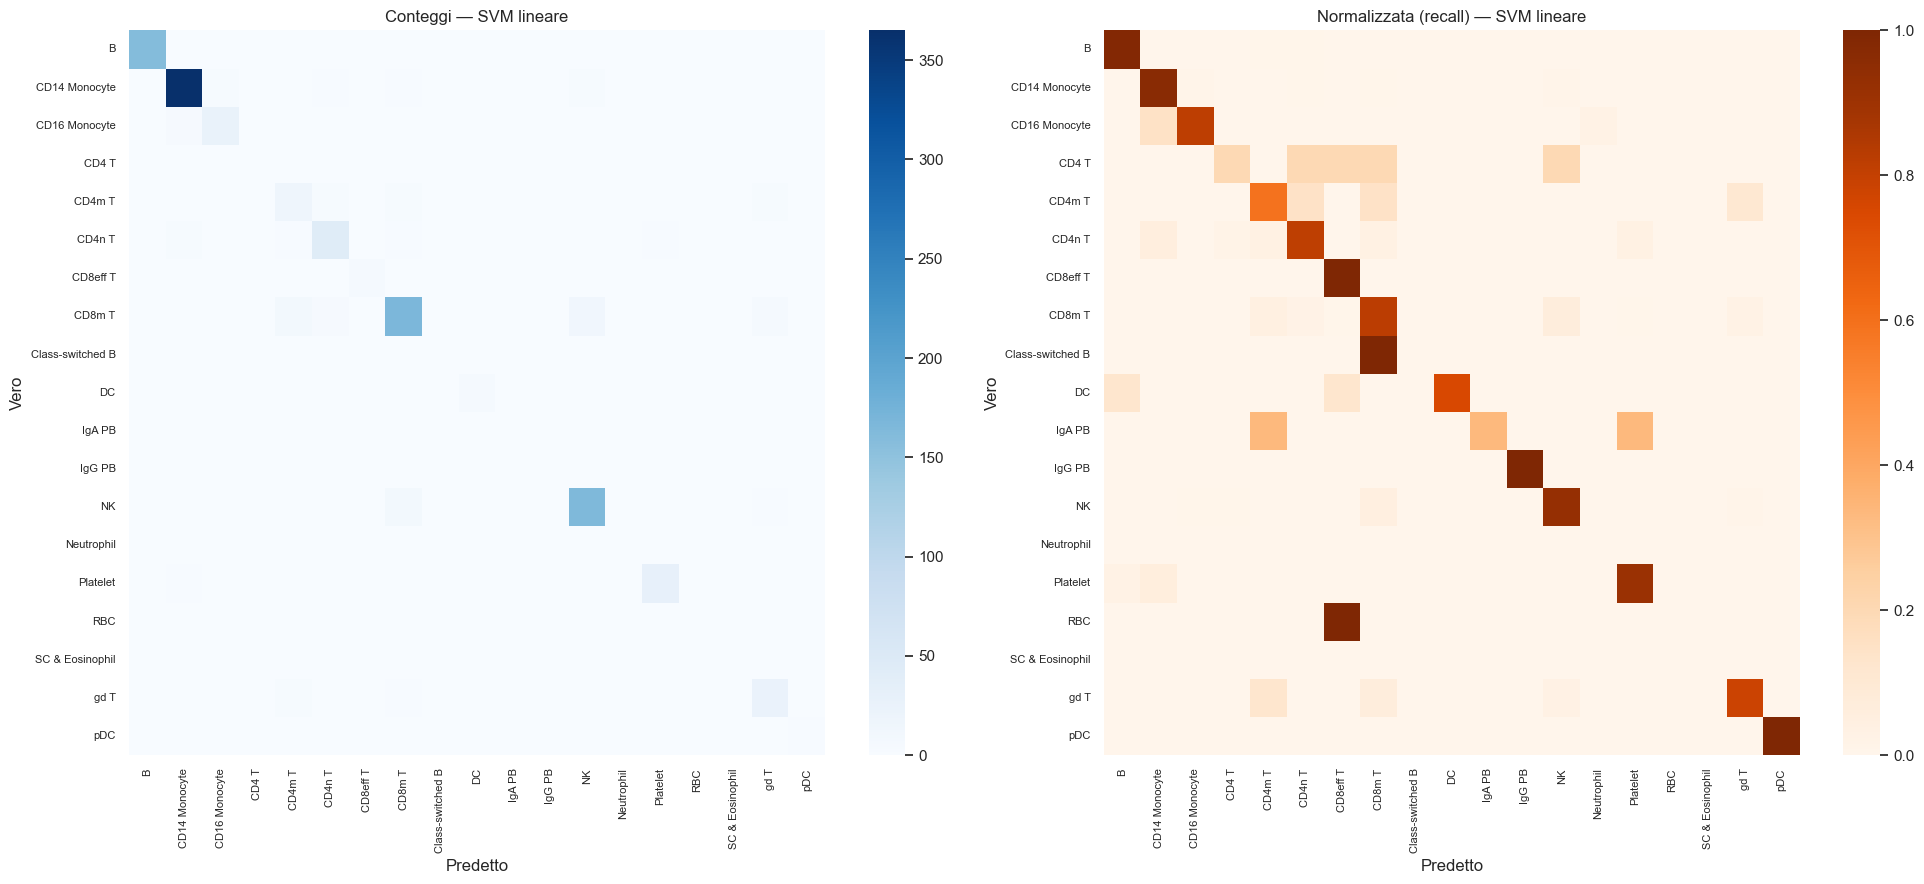


  Random Forest  (tempo: 1.2s)
  Accuracy:          0.8866
  Macro F1:          0.7102
  Macro Precision:   0.6924
  Macro Recall:      0.7389
  Balanced Accuracy: 0.7389
                  precision    recall  f1-score   support

               B       1.00      0.99      0.99       162
   CD14 Monocyte       0.98      0.94      0.96       378
   CD16 Monocyte       0.76      0.97      0.85        33
           CD4 T       0.33      0.20      0.25         5
          CD4m T       0.36      0.52      0.42        27
          CD4n T       0.64      0.81      0.72        54
        CD8eff T       0.86      1.00      0.92         6
          CD8m T       0.89      0.78      0.83       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.70      0.88      0.78         8
          IgA PB       0.75      1.00      0.86         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.89      0.93      0.91       178
      Neutrophi

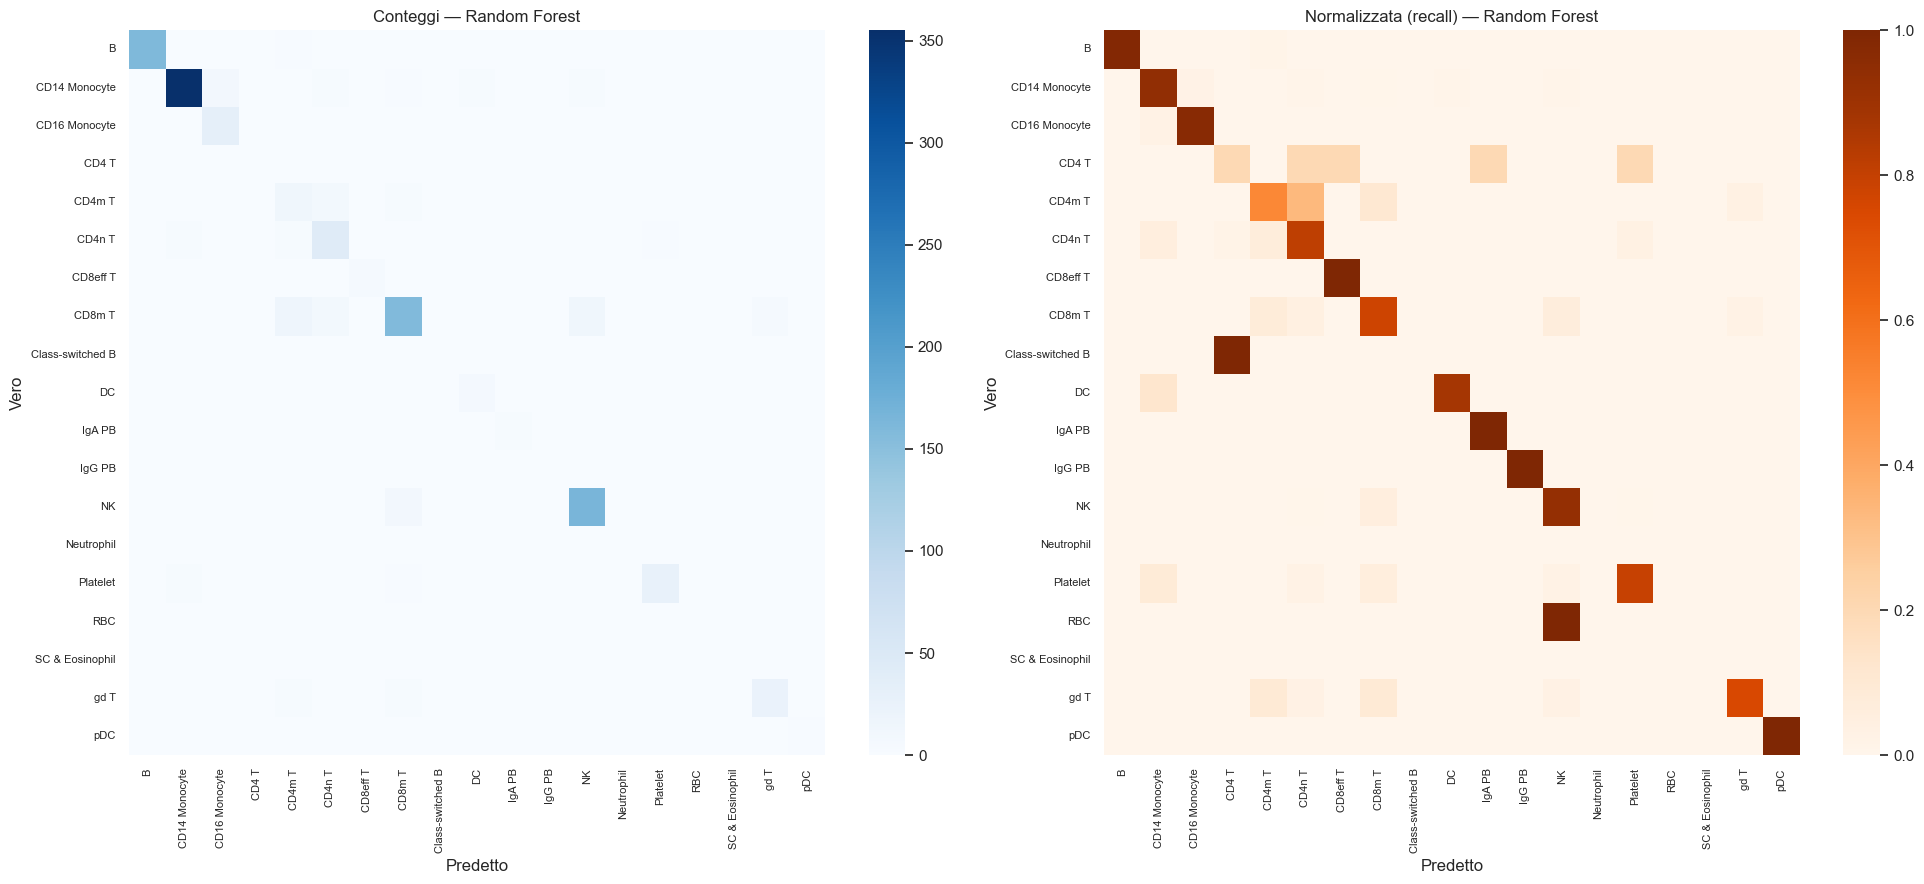


  LightGBM  (tempo: 151.2s)
  Accuracy:          0.8911
  Macro F1:          0.6605
  Macro Precision:   0.6705
  Macro Recall:      0.6583
  Balanced Accuracy: 0.6583
                  precision    recall  f1-score   support

               B       1.00      0.99      0.99       162
   CD14 Monocyte       0.96      0.96      0.96       378
   CD16 Monocyte       0.81      0.79      0.80        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.44      0.26      0.33        27
          CD4n T       0.78      0.80      0.79        54
        CD8eff T       0.50      0.33      0.40         6
          CD8m T       0.81      0.88      0.84       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.86      0.75      0.80         8
          IgA PB       0.75      1.00      0.86         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.91      0.93      0.92       178
      Neutrophil  

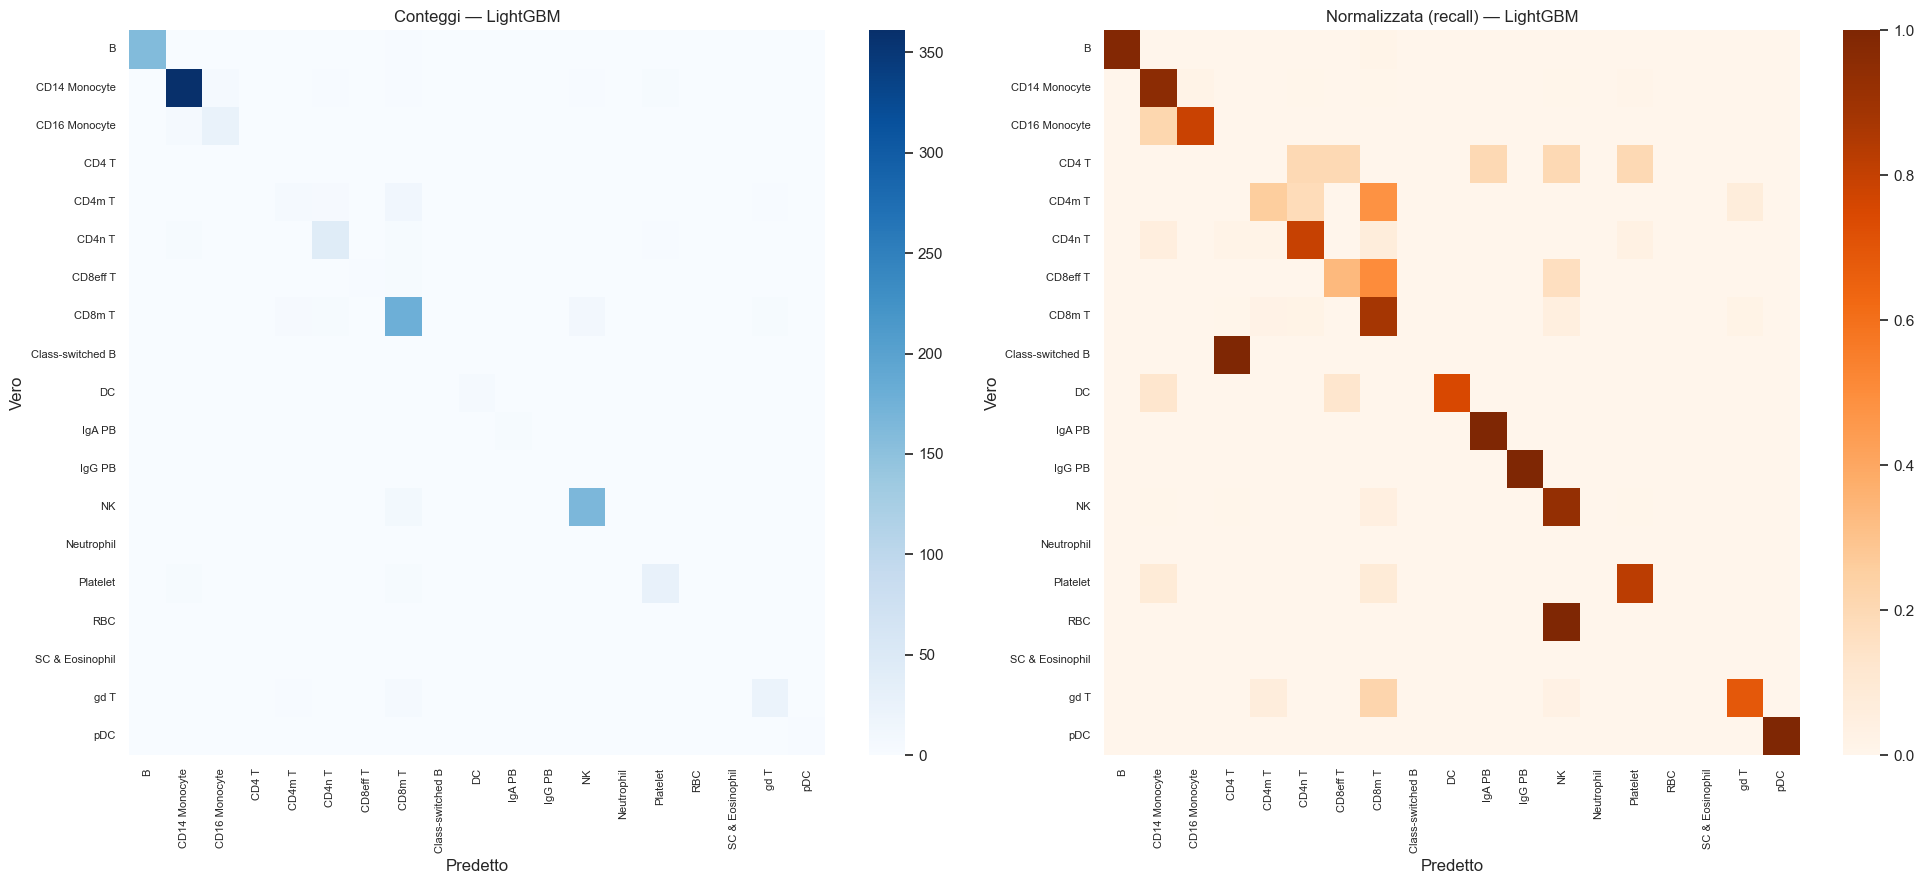

In [57]:
classifiers: dict[str, Classifier] = {}

for name, model in model_definitions.items():
    clf = Classifier(name, model)
    clf.fit(X_train.values, y_train.values)
    clf.evaluate(X_test.values, y_test)
    clf.print_report(y_test)
    clf.plot_confusion(y_test)
    classifiers[name] = clf


## 5. Confronto delle performance (default)



Riepilogo finale (ordinato per Macro F1)
                     accuracy  macro_f1  macro_precision  macro_recall  balanced_accuracy
SVM lineare            0.9035    0.7256           0.7149        0.7495             0.7495
Random Forest          0.8707    0.6672           0.6307        0.7366             0.7366
LightGBM               0.8902    0.6582           0.6659        0.6572             0.6572
Logistic Regression    0.8866    0.6535           0.6415        0.6911             0.6911
Dummy                  0.3348    0.0295           0.0197        0.0588             0.0588


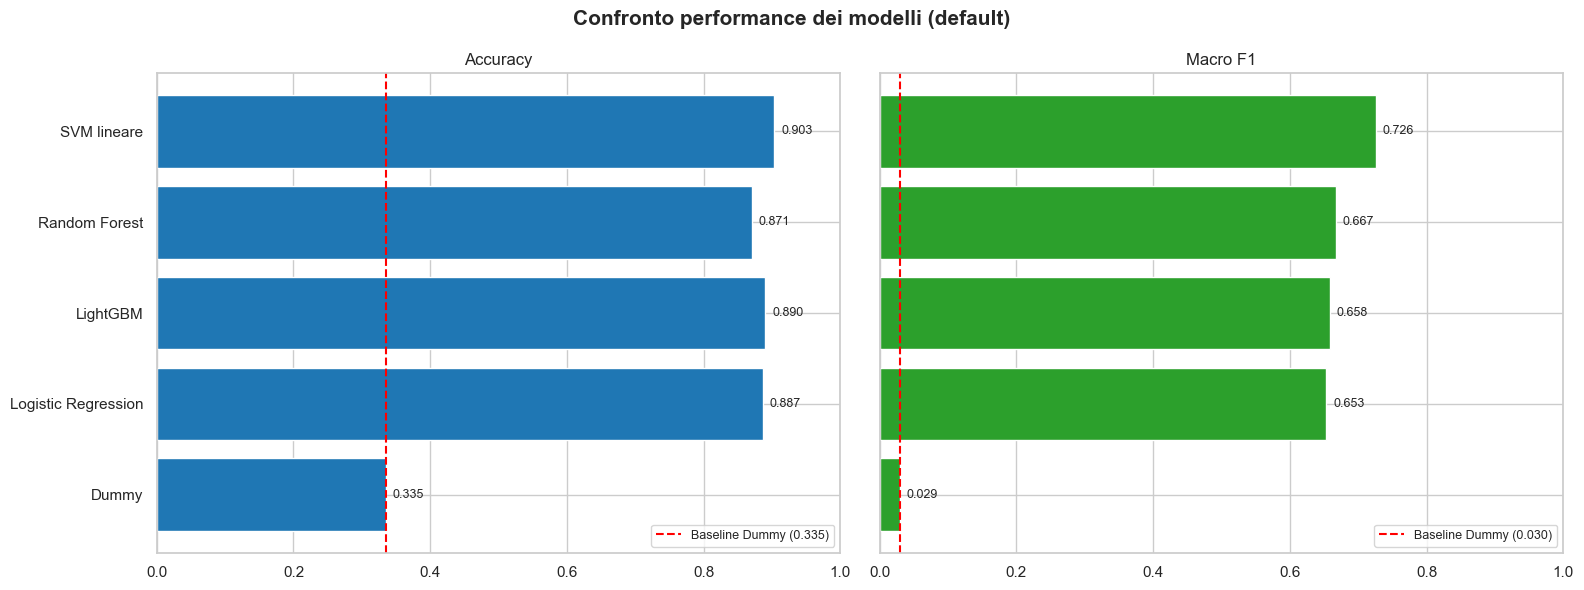

In [71]:
summary = (
    pd.DataFrame({name: clf.metrics for name, clf in classifiers.items()})
    .T.round(4)
    .sort_values("macro_f1", ascending=False)
)
print("\nRiepilogo finale (ordinato per Macro F1)")
print(summary.to_string())

dummy_acc = classifiers["Dummy"].metrics["accuracy"]
dummy_f1  = classifiers["Dummy"].metrics["macro_f1"]
names     = summary.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle("Confronto performance dei modelli (default)", fontsize=15, fontweight="bold")

for ax, col, color, dummy_val, title in zip(
    axes, ["accuracy", "macro_f1"], ["#1f77b4", "#2ca02c"],
    [dummy_acc, dummy_f1], ["Accuracy", "Macro F1"],
):
    ax.barh(names, summary[col], color=color)
    ax.axvline(dummy_val, color="red", ls="--", lw=1.5,
               label=f"Baseline Dummy ({dummy_val:.3f})")
    ax.set_title(title); ax.set_xlim(0, 1); ax.legend(fontsize=9)
    for i, v in enumerate(summary[col]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

axes[0].invert_yaxis()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confronto_modelli_default.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Hyperparameter Tuning




In [59]:
# Setup CV (solo train set)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

min_class = min(Counter(y_train).values())
n_splits = min(5, min_class)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"CV stratificata: {n_splits} fold (classe piu rara: {min_class} celle)")


CV stratificata: 2 fold (classe piu rara: 2 celle)


In [60]:
# Random Forest
param_dist_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 7, 10],
    "min_samples_split": [2, 5, 10],
}

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=1,  
)

search_rf = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist_rf,
    n_iter=6,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("── Tuning Random Forest ──")
search_rf.fit(X_train.values, y_train.values)
print(f"\nMiglior Macro F1 (CV): {search_rf.best_score_:.4f}")
print("Migliori parametri:", search_rf.best_params_)


── Tuning Random Forest ──
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Miglior Macro F1 (CV): 0.5462
Migliori parametri: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


In [61]:
# LightGBM
if HAS_LGBM:
    param_dist_lgbm = {
        "n_estimators": [100, 200],
        "max_depth": [4, 7, 10],
        "num_leaves": [15, 31, 63],
    }

    lgbm_base = LGBMClassifier(
        objective="multiclass",
        num_class=N_CLASSES,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
        verbosity=-1,
    )

    search_lgbm = RandomizedSearchCV(
        lgbm_base,
        param_distributions=param_dist_lgbm,
        n_iter=6,
        scoring="f1_macro",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

    print("── Tuning LightGBM ──")
    search_lgbm.fit(X_train.values, y_train.values)
    print(f"\nMiglior Macro F1 (CV): {search_lgbm.best_score_:.4f}")
    print("Migliori parametri:", search_lgbm.best_params_)
else:
    print("LightGBM non disponibile — tuning saltato.")


── Tuning LightGBM ──
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Miglior Macro F1 (CV): 0.5436
Migliori parametri: {'num_leaves': 15, 'n_estimators': 200, 'max_depth': 4}


In [62]:
# SVM lineare — tuning di C, con PCA(100) fisso
param_dist_svm = {"svm__C": [0.1, 1, 10]}

svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, random_state=42)),
    ("svm", LinearSVC(class_weight="balanced", max_iter=2000, random_state=42)),
])

search_svm = RandomizedSearchCV(
    svm_base,
    param_distributions=param_dist_svm,
    n_iter=3,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("── Tuning SVM lineare (C, con PCA(100) fissa) ──")
search_svm.fit(X_train.values, y_train.values)
print(f"\nMiglior Macro F1 (CV): {search_svm.best_score_:.4f}")
print("Migliori parametri:", search_svm.best_params_)


── Tuning SVM lineare (C, con PCA(100) fissa) ──
Fitting 2 folds for each of 3 candidates, totalling 6 fits

Miglior Macro F1 (CV): 0.5533
Migliori parametri: {'svm__C': 0.1}



── Valutazione finale sul test set (modelli tunati) ──

  Random Forest  (tempo: 0.0s)
  Accuracy:          0.8707
  Macro F1:          0.6672
  Macro Precision:   0.6307
  Macro Recall:      0.7366
  Balanced Accuracy: 0.7366
                  precision    recall  f1-score   support

               B       1.00      0.99      0.99       162
   CD14 Monocyte       0.98      0.93      0.96       378
   CD16 Monocyte       0.73      0.97      0.83        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.40      0.78      0.53        27
          CD4n T       0.71      0.76      0.73        54
        CD8eff T       0.50      1.00      0.67         6
          CD8m T       0.92      0.66      0.77       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.70      0.88      0.78         8
          IgA PB       0.60      1.00      0.75         3
          IgG PB       1.00      1.00      1.00         1
              NK 

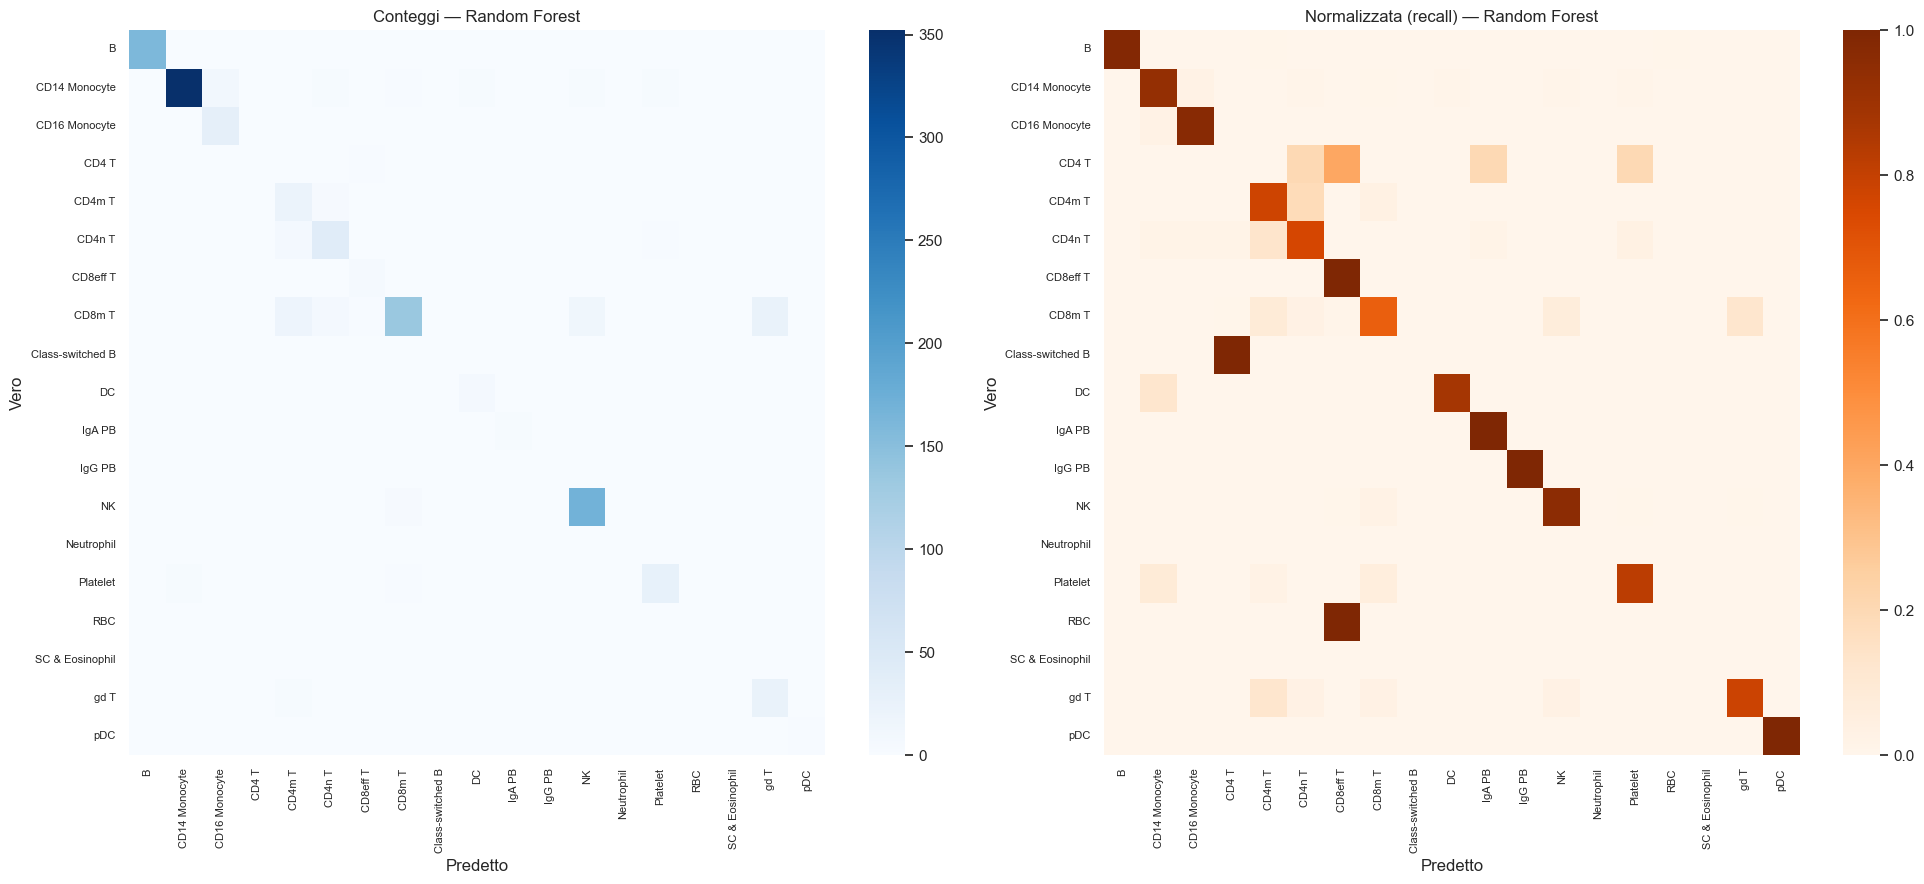


  LightGBM  (tempo: 0.0s)
  Accuracy:          0.8902
  Macro F1:          0.6582
  Macro Precision:   0.6659
  Macro Recall:      0.6572
  Balanced Accuracy: 0.6572
                  precision    recall  f1-score   support

               B       1.00      0.99      0.99       162
   CD14 Monocyte       0.96      0.96      0.96       378
   CD16 Monocyte       0.83      0.76      0.79        33
           CD4 T       0.00      0.00      0.00         5
          CD4m T       0.44      0.26      0.33        27
          CD4n T       0.79      0.81      0.80        54
        CD8eff T       0.40      0.33      0.36         6
          CD8m T       0.79      0.88      0.83       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.75      0.75      0.75         8
          IgA PB       0.75      1.00      0.86         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.89      0.93      0.91       178
      Neutrophil    

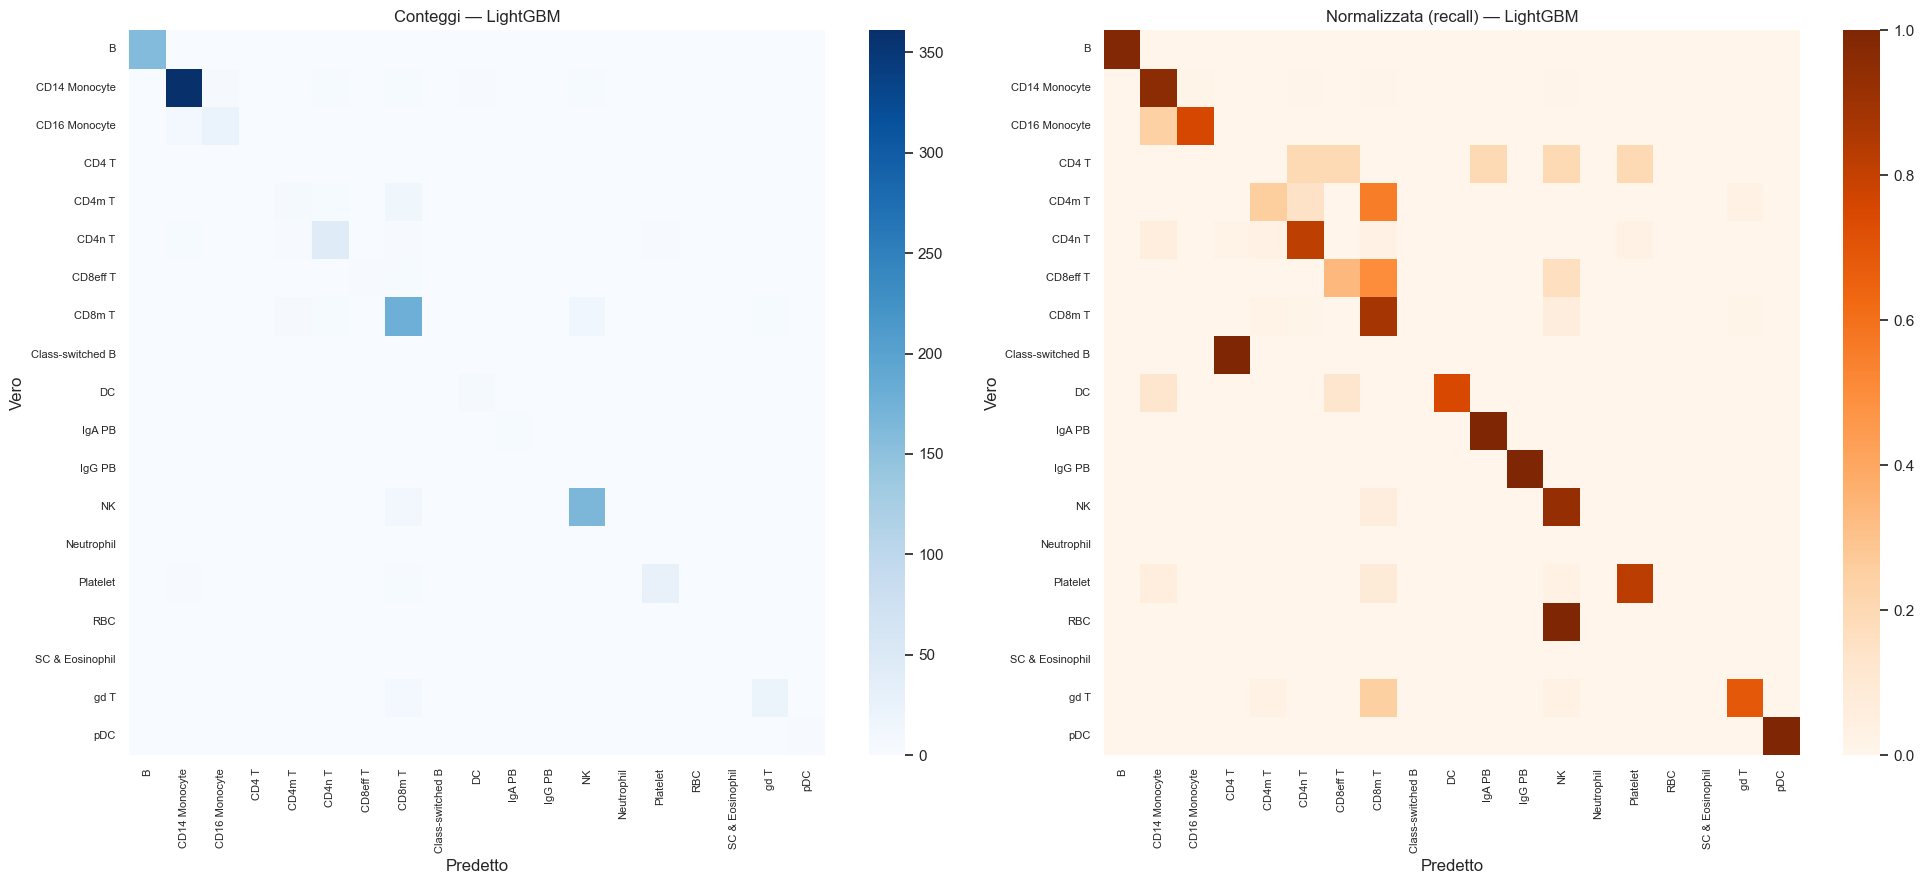


  SVM lineare  (tempo: 0.0s)
  Accuracy:          0.9035
  Macro F1:          0.7256
  Macro Precision:   0.7149
  Macro Recall:      0.7495
  Balanced Accuracy: 0.7495
                  precision    recall  f1-score   support

               B       0.99      0.99      0.99       162
   CD14 Monocyte       0.98      0.95      0.96       378
   CD16 Monocyte       0.78      0.88      0.83        33
           CD4 T       0.43      0.60      0.50         5
          CD4m T       0.50      0.59      0.54        27
          CD4n T       0.78      0.87      0.82        54
        CD8eff T       0.60      1.00      0.75         6
          CD8m T       0.91      0.82      0.86       204
Class-switched B       0.00      0.00      0.00         1
              DC       0.75      0.75      0.75         8
          IgA PB       1.00      0.67      0.80         3
          IgG PB       1.00      1.00      1.00         1
              NK       0.90      0.93      0.92       178
      Neutrophil 

In [63]:
# Valutazione finale sul test set (modelli tunati)
TUNED_MODELS = ["Random Forest", "SVM lineare"] + (["LightGBM"] if HAS_LGBM else [])
default_metrics = {
    name: classifiers[name].metrics.copy()
    for name in TUNED_MODELS
    if name in classifiers
}

print("\n── Valutazione finale sul test set (modelli tunati) ──")

clf_rf_tuned = Classifier("Random Forest", search_rf.best_estimator_)
clf_rf_tuned.evaluate(X_test.values, y_test)
clf_rf_tuned.print_report(y_test)
clf_rf_tuned.plot_confusion(y_test)
classifiers["Random Forest"] = clf_rf_tuned

if HAS_LGBM:
    clf_lgbm_tuned = Classifier("LightGBM", search_lgbm.best_estimator_)
    clf_lgbm_tuned.evaluate(X_test.values, y_test)
    clf_lgbm_tuned.print_report(y_test)
    clf_lgbm_tuned.plot_confusion(y_test)
    classifiers["LightGBM"] = clf_lgbm_tuned

clf_svm_tuned = Classifier("SVM lineare", search_svm.best_estimator_)
clf_svm_tuned.evaluate(X_test.values, y_test)
clf_svm_tuned.print_report(y_test)
classifiers["SVM lineare"] = clf_svm_tuned


### 6.1 Riepiologo Performance Default vs Tunato


── Default vs Tunato ──
               Macro_F1 default  Macro_F1 tuning
Random Forest            0.7102           0.6672
SVM lineare              0.6471           0.7256
LightGBM                 0.6605           0.6582


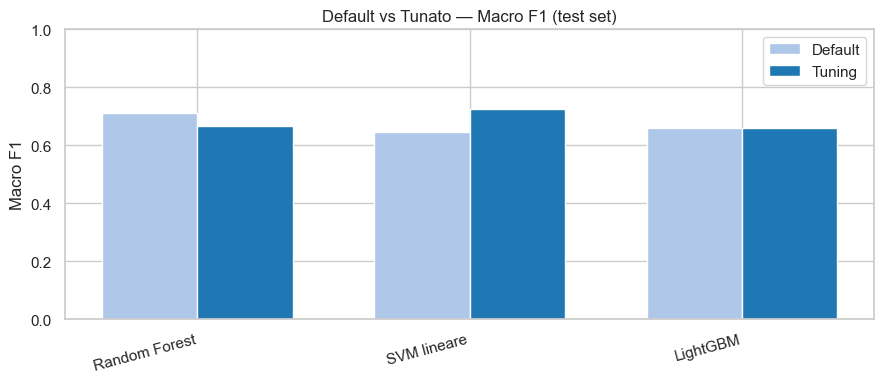

In [64]:
# Default vs Tunato (Macro F1 sul test set)
confronto_f1 = pd.DataFrame({
    "Macro_F1 default": [default_metrics[n]["macro_f1"] for n in TUNED_MODELS],
    "Macro_F1 tuning": [classifiers[n].metrics["macro_f1"] for n in TUNED_MODELS],
}, index=TUNED_MODELS).round(4)

print("── Default vs Tunato ──")
print(confronto_f1.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(confronto_f1))
w = 0.35
ax.bar([i - w / 2 for i in x], confronto_f1["Macro_F1 default"], width=w,
       label="Default", color="#aec7e8")
ax.bar([i + w / 2 for i in x], confronto_f1["Macro_F1 tuning"], width=w,
       label="Tuning", color="#1f77b4")
ax.set_xticks(list(x))
ax.set_xticklabels(confronto_f1.index, rotation=15, ha="right")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_title("Default vs Tunato — Macro F1 (test set)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "confronto_f1_default_vs_tunato.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Feature importance  (RF e LightGBM)




Miglior modello ad alberi (Macro F1 CV): Random Forest
  best_score CV: 0.5462
  best_params  : {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}

── Feature importance: Random Forest (tunato) ──
   Parametri CV: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


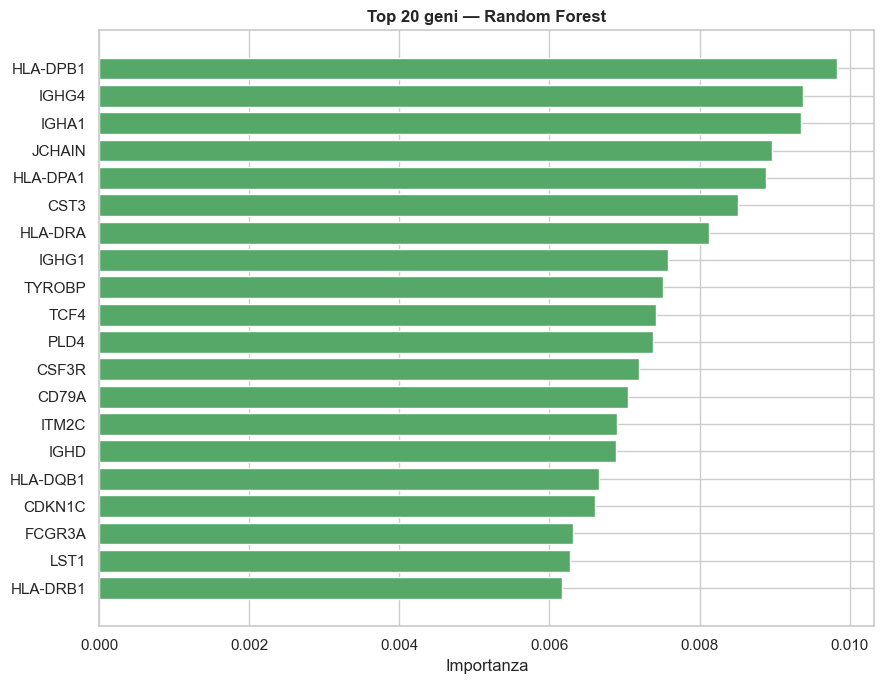

   Top 5: HLA-DPB1, IGHG4, IGHA1, JCHAIN, HLA-DPA1

── Feature importance: LightGBM (tunato) ──
   Parametri CV: {'num_leaves': 15, 'n_estimators': 200, 'max_depth': 4}


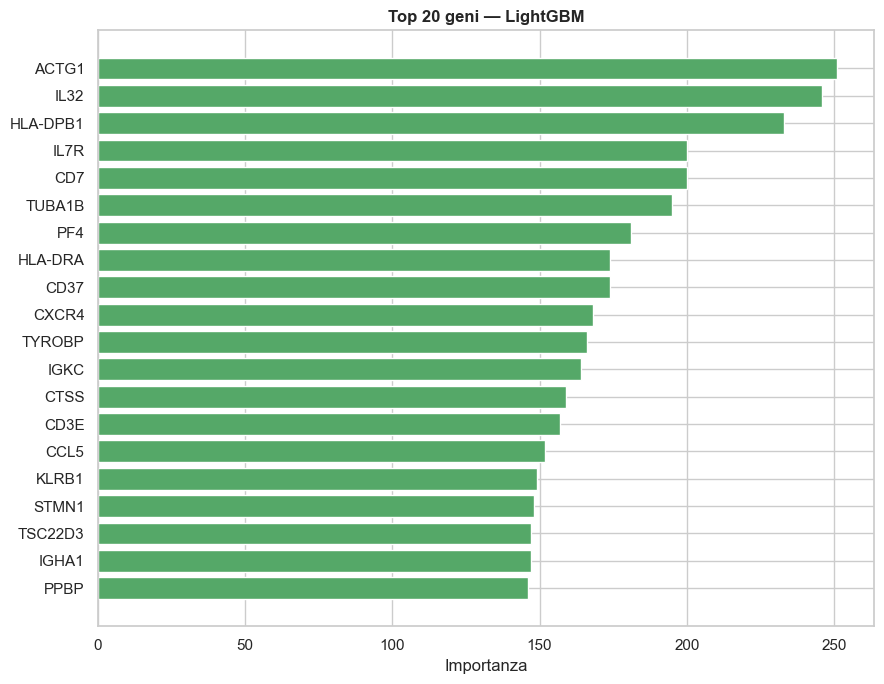

   Top 5: ACTG1, IL32, HLA-DPB1, IL7R, CD7



In [65]:
# Feature importance (miglior macro_f1 in CV)
tree_searches = [("Random Forest", search_rf)]
if HAS_LGBM:
    tree_searches.append(("LightGBM", search_lgbm))

best_name, best_search = max(tree_searches, key=lambda x: x[1].best_score_)
print(f"Miglior modello ad alberi (Macro F1 CV): {best_name}")
print(f"  best_score CV: {best_search.best_score_:.4f}")
print(f"  best_params  : {best_search.best_params_}\n")

for name, search in tree_searches:
    print(f"── Feature importance: {name} (tunato) ──")
    print(f"   Parametri CV: {search.best_params_}")
    clf_tuned = Classifier(name, search.best_estimator_)
    imp = clf_tuned.feature_importance(X_train.columns)
    if imp is not None:
        print("   Top 5:", ", ".join(imp.nlargest(5).index.tolist()))
    print()


## 8. SHAP 


SHAP sul modello tunato: Random Forest
  best_params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


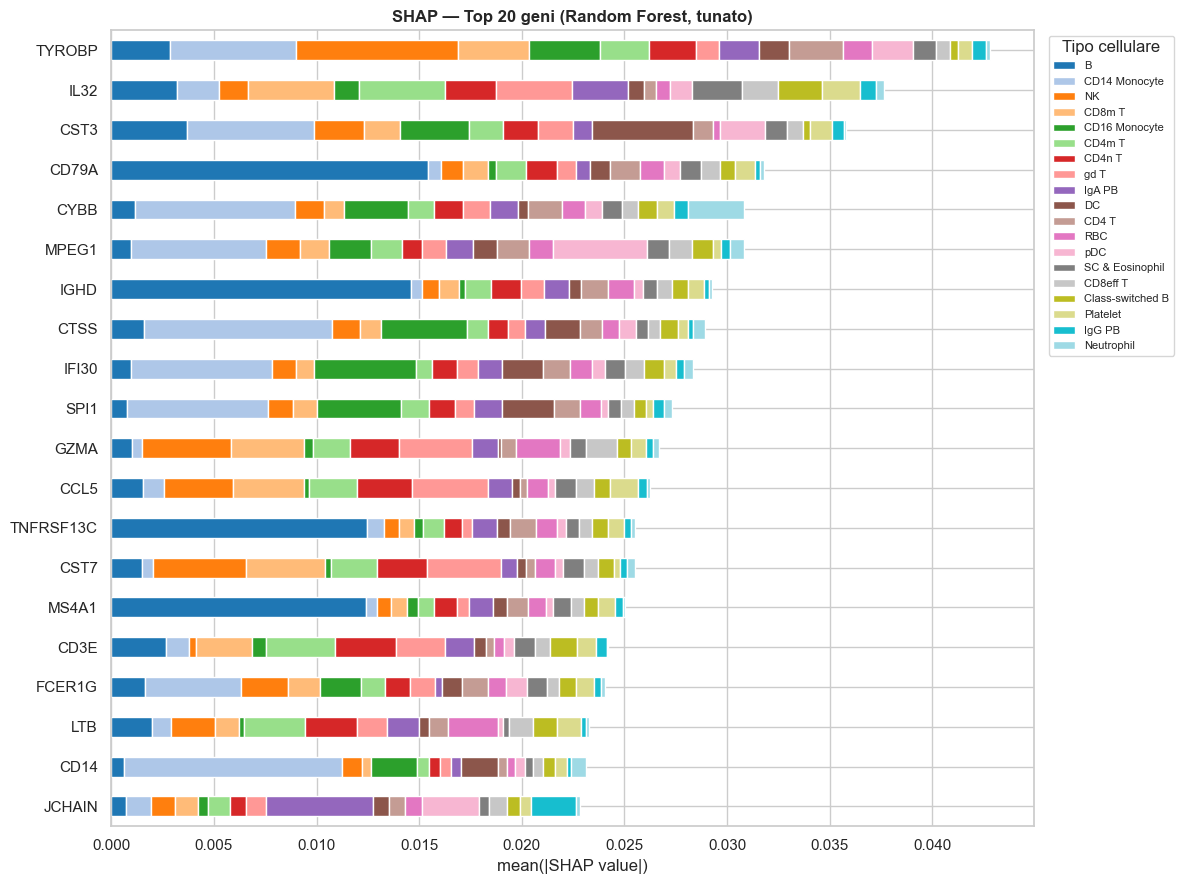

In [66]:
try:
    import shap

    best_name, best_search = max(tree_searches, key=lambda x: x[1].best_score_)
    model = best_search.best_estimator_
    print(f"SHAP sul modello tunato: {best_name}")
    print(f"  best_params: {best_search.best_params_}")

    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_test), size=min(200, len(X_test)), replace=False)
    X_sample = X_test.iloc[idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample.values)

    sv_array = np.stack(shap_values, axis=-1) if isinstance(shap_values, list) else shap_values
    class_names = list(model.classes_)

    mean_shap = pd.DataFrame(
        np.abs(sv_array).mean(axis=0),
        index=X_sample.columns,
        columns=class_names,
    )

    top20 = mean_shap.sum(axis=1).nlargest(20).index
    class_order = mean_shap.loc[top20].sum(axis=0).sort_values(ascending=False).index
    plot_df = mean_shap.loc[top20, class_order].iloc[::-1]

    fig, ax = plt.subplots(figsize=(12, 9))
    plot_df.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
    ax.set_xlabel("mean(|SHAP value|)")
    ax.set_title(f"SHAP — Top 20 geni ({best_name}, tunato)", fontweight="bold")
    ax.legend(title="Tipo cellulare", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "shap_top20.png", dpi=150, bbox_inches="tight")
    plt.show()

except ImportError:
    print("shap non installato. Installare con: pip install shap")


## 9. Esperimento 1: tutti i geni vs geni discriminanti (criterio 1σ EDA)


In [67]:
def make_tree_model(name: str):
    """Restituisce una nuova istanza pulita del modello ad alberi scelto
    (stessi iperparametri tunati in sezione 6)."""
    if name == "LightGBM" and HAS_LGBM:
        return LGBMClassifier(**search_lgbm.best_params_,
                               objective="multiclass", num_class=N_CLASSES,
                               class_weight="balanced", random_state=42,
                               n_jobs=-1, verbosity=-1)
    return RandomForestClassifier(**search_rf.best_params_,
                                   class_weight="balanced",
                                   random_state=42, n_jobs=-1)


df_tr       = X_train.copy(); df_tr["cell_type"] = y_train.values
spread      = df_tr.groupby("cell_type").mean().pipe(lambda d: d.max() - d.min())
ratio_sigma = spread / X_train.std()
geni_discr  = ratio_sigma[ratio_sigma > 1].index.tolist()

print(f"Geni discriminanti (ratio > 1σ): {len(geni_discr)} su {X_train.shape[1]}")
print(f"Modello usato per l'esperimento: {best_name}")

clf_d = Classifier(f"{best_name} (1σ)", make_tree_model(best_name))
clf_d.fit(X_train[geni_discr].values, y_train.values)
clf_d.evaluate(X_test[geni_discr].values, y_test)

confronto_sigma = pd.DataFrame({
    "Macro_F1 default": [classifiers[best_name].metrics["macro_f1"]],
    "Macro_F1 (1σ)": [clf_d.metrics["macro_f1"]],
}, index=[best_name]).round(4)

print(f"\n── Tutti i geni ({X_train.shape[1]}) vs geni discriminanti (1σ, {len(geni_discr)}) ──")
print(confronto_sigma.to_string())


Geni discriminanti (ratio > 1σ): 1199 su 1976
Modello usato per l'esperimento: Random Forest

── Tutti i geni (1976) vs geni discriminanti (1σ, 1199) ──
               Macro_F1 default  Macro_F1 (1σ)
Random Forest            0.6672         0.6917


## 10. Esperimento 2: X_train originale vs X_train + scores di gruppo (sezione 5. EDA)


In [68]:
DATA_DIR = ROOT / "data_train"
scores_path_train = DATA_DIR / "scores_train.csv"
scores_path_test  = DATA_DIR / "scores_test.csv"

if scores_path_train.exists() and scores_path_test.exists():
    scores_train = pd.read_csv(scores_path_train, index_col=0)
    scores_test  = pd.read_csv(scores_path_test,  index_col=0)

    X_tr_aug = pd.concat([X_train.reset_index(drop=True),
                           scores_train.reset_index(drop=True)], axis=1)
    X_te_aug = pd.concat([X_test.reset_index(drop=True),
                           scores_test.reset_index(drop=True)], axis=1)

    print(f"Feature originali: {X_train.shape[1]}  →  con scores: {X_tr_aug.shape[1]}")

    clf_aug = Classifier(f"{best_name} (+scores)", make_tree_model(best_name))
    clf_aug.fit(X_tr_aug.values, y_train.values)
    clf_aug.evaluate(X_te_aug.values, y_test)

    confronto_scores = pd.DataFrame({
        "Macro_F1 default": [classifiers[best_name].metrics["macro_f1"]],
        "Macro_F1 (+scores)": [clf_aug.metrics["macro_f1"]],
    }, index=[best_name]).round(4)

    print("\n── Originale vs con scores di gruppo ──")
    print(confronto_scores.to_string())
else:
    print("scores_train.csv / scores_test.csv non trovati — salto sezione 10.")
    print(f"Attesi in: {DATA_DIR}")


Feature originali: 1976  →  con scores: 1984

── Originale vs con scores di gruppo ──
               Macro_F1 default  Macro_F1 (+scores)
Random Forest            0.6672              0.6764
